# Method 2 — Elastic Net Synthetic Control (EN-SCM)
## L1 + L2 Regularised Weight Estimation

**What this notebook does:**
Standard SCM with a constrained (sum-to-one, non-negative) weight constraint can become
brittle when donors are correlated or when one donor dominates. Elastic Net SCM replaces
the hard constraint with a penalised objective: minimise pre-period fit error plus an
L1+L2 penalty on the weights. This produces sparser, more stable donor weights.

Key distinction from ASCM: EN-SCM changes *how weights are found* (regularised
optimisation). ASCM keeps vanilla SCM weights and adds a bias correction layer.

**Structure:**
1. Environment & shared utilities  
2. Data loading & audit  
3. Blocked CV over (alpha, l1_ratio) grid — full 2-D search  
4. EN-SCM estimation — final fit  
5. Weight analysis: sparsity, concentration, vs Base SCM  
6. Counterfactual & gap series  
7. Validation A — In-time placebo tests  
8. Validation B — Leave-one-year-out stability  
9. Validation C — (alpha, l1_ratio) sensitivity heatmap  
10. Figure panel  
11. Summary table & comparison  


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Environment & Imports
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
import itertools
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--', 'font.size': 10,
})

BLUE = '#0f3460'; RED = '#e94560'; GREY = '#aaaaaa'; GREEN = '#2ecc71'; AMBER = '#f39c12'
print("All imports successful.")


All imports successful.


## Shared Utility Functions

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Shared Utility Functions
# ═══════════════════════════════════════════════════════════════════════════════

def fit_scm_constrained(Y_pre, X_pre):
    """Vanilla SCM: weights ≥ 0, sum = 1, minimise pre-RMSPE."""
    if X_pre.ndim == 1: X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]
    res = minimize(
        lambda w: np.sum((Y_pre - X_pre @ w)**2),
        np.ones(n)/n, method='SLSQP',
        bounds=[(0, 1)]*n,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1},
        options={'ftol': 1e-12, 'maxiter': 5000}
    )
    return np.clip(res.x, 0, None)


def fit_elastic_scm(Y_pre, X_pre, alpha=0.01, l1_ratio=0.5):
    """
    Elastic Net SCM: minimise MSE + alpha*[l1_ratio*||w||_1 + 0.5*(1-l1_ratio)*||w||_2^2]
    subject to w >= 0 (non-negativity; sum constraint is softened by regularisation).
    
    Note: we keep w >= 0 but drop the sum=1 hard constraint. The L2 term
    naturally prevents unbounded weights. We then report weight concentration.
    
    Parameters
    ----------
    alpha     : overall regularisation strength
    l1_ratio  : mixing parameter (0 = pure ridge, 1 = pure lasso)
    """
    if X_pre.ndim == 1: X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]

    def loss(w):
        resid = Y_pre - X_pre @ w
        mse   = np.mean(resid**2)
        l1    = alpha * l1_ratio       * np.sum(np.abs(w))
        l2    = alpha * (1-l1_ratio) * 0.5 * np.sum(w**2)
        return mse + l1 + l2

    res = minimize(
        loss, np.ones(n)/n, method='SLSQP',
        bounds=[(0, None)]*n,
        options={'ftol': 1e-14, 'maxiter': 10000}
    )
    w = np.clip(res.x, 0, None)
    return w


def rmspe(a, b):
    return np.sqrt(np.mean((np.asarray(a) - np.asarray(b))**2))

def mape(a, b):
    a = np.asarray(a)
    return np.mean(np.abs((a - b) / np.where(a==0, 1e-10, a))) * 100

def herfindahl(weights):
    """Herfindahl-Hirschman Index: sum of squared weight shares. 1 = full concentration."""
    w = np.asarray(weights)
    if w.sum() == 0: return np.nan
    shares = w / w.sum()
    return np.sum(shares**2)

def effective_donors(weights):
    """Effective number of donors = 1/HHI."""
    h = herfindahl(weights)
    return 1/h if h > 0 else np.nan

print("Functions defined: fit_scm_constrained, fit_elastic_scm, rmspe, mape, herfindahl, effective_donors")


Functions defined: fit_scm_constrained, fit_elastic_scm, rmspe, mape, herfindahl, effective_donors


## Data Loading & Audit

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Data Loading & Audit
# ═══════════════════════════════════════════════════════════════════════════════

CSV_PATH = '../data/corridor.csv'

df = pd.read_csv(CSV_PATH)
df['Date']        = df['Date'].astype(str).str.strip()
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'], freq='M')

Y_COL       = 'Rail_Vol_mt'
TREATED     = 'NATCOR'
TREAT_START = pd.Period('2022-04', freq='M')
PRE_END     = TREAT_START - 1

wide     = df.pivot(index='Date_period', columns='Corridor', values=Y_COL).sort_index()
donors   = [c for c in wide.columns if c != TREATED]
pre_idx  = wide.index[wide.index <= PRE_END]
post_idx = wide.index[wide.index >= TREAT_START]
T_pre    = len(pre_idx)
T_post   = len(post_idx)
T_total  = len(wide)
t_stamps = wide.index.to_timestamp()
treat_t  = TREAT_START.to_timestamp()

Y_all   = wide[TREATED].values
X_all   = wide[donors[0]].values
Y_pre_v = wide.loc[pre_idx, TREATED].values
X_pre_v = wide.loc[pre_idx, donors[0]].values.reshape(-1, 1)

# Base SCM for comparison
w_scm    = fit_scm_constrained(Y_pre_v, X_pre_v)
cf_scm   = X_all * w_scm[0]
base_pre_r  = rmspe(Y_all[:T_pre], cf_scm[:T_pre])
base_post_r = rmspe(Y_all[T_pre:], cf_scm[T_pre:])
base_ratio  = base_post_r / base_pre_r
base_cum    = (Y_all[T_pre:] - cf_scm[T_pre:]).sum()

print("─" * 55)
print(f"Treated unit  : {TREATED}  |  Donors: {donors}")
print(f"Pre-period    : {pre_idx[0]} → {pre_idx[-1]}  ({T_pre} months)")
print(f"Post-period   : {post_idx[0]} → {post_idx[-1]}  ({T_post} months)")
print(f"Missing values: {wide.isnull().sum().sum()}")
print("─" * 55)
print()
print("Base SCM reference:")
print(f"  Weight: {dict(zip(donors, w_scm.round(4)))}")
print(f"  HHI: {herfindahl(w_scm):.4f}  |  Effective donors: {effective_donors(w_scm):.2f}")
print(f"  Pre-RMSPE: {base_pre_r:.4f}  |  Post-RMSPE: {base_post_r:.4f}  |  Ratio: {base_ratio:.4f}")
print(f"  Cumulative effect: {base_cum:.4f} MT")


───────────────────────────────────────────────────────
Treated unit  : NATCOR  |  Donors: ['CAPE']
Pre-period    : 2015-01 → 2022-03  (87 months)
Post-period   : 2022-04 → 2024-12  (33 months)
Missing values: 0
───────────────────────────────────────────────────────

Base SCM reference:
  Weight: {'CAPE': np.float64(1.0)}
  HHI: 1.0000  |  Effective donors: 1.00
  Pre-RMSPE: 0.2132  |  Post-RMSPE: 0.3653  |  Ratio: 1.7140
  Cumulative effect: -11.1040 MT


## 2-D Blocked Cross-Validation: (alpha, l1_ratio) Grid Search

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — 2-D Blocked CV: select alpha AND l1_ratio jointly
# ═══════════════════════════════════════════════════════════════════════════════
# We run a full grid over alpha (regularisation strength) and l1_ratio
# (Lasso vs Ridge mixing). Blocked split: train 60% / validate 40% of pre-period.
# No random shuffling — time ordering is preserved throughout.

alpha_grid   = [1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1, 0.5, 1.0]
l1ratio_grid = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]

split_pt = int(0.60 * T_pre)
X_tr = X_pre_v[:split_pt];  Y_tr = Y_pre_v[:split_pt]
X_va = X_pre_v[split_pt:];  Y_va = Y_pre_v[split_pt:]

print(f"Blocked CV: train 0→{split_pt-1} ({split_pt} obs), validate {split_pt}→{T_pre-1} ({T_pre-split_pt} obs)")
print(f"Grid: {len(alpha_grid)} alphas × {len(l1ratio_grid)} l1_ratios = {len(alpha_grid)*len(l1ratio_grid)} combinations")
print()

cv_grid = []
for a, l1r in itertools.product(alpha_grid, l1ratio_grid):
    w_cv   = fit_elastic_scm(Y_tr, X_tr, alpha=a, l1_ratio=l1r)
    cf_va  = X_va @ w_cv
    cf_tr  = X_tr @ w_cv
    val_e  = rmspe(Y_va, cf_va)
    tr_e   = rmspe(Y_tr, cf_tr)
    cv_grid.append({
        'alpha': a, 'l1_ratio': l1r,
        'val_RMSPE': round(val_e, 6),
        'train_RMSPE': round(tr_e, 6),
        'weight_sum': round(w_cv.sum(), 4),
        'HHI': round(herfindahl(w_cv), 4)
    })

cv_df = pd.DataFrame(cv_grid).sort_values('val_RMSPE')
best = cv_df.iloc[0]
BEST_ALPHA    = best['alpha']
BEST_L1_RATIO = best['l1_ratio']

print("Top 10 hyperparameter combinations:")
print(cv_df.head(10).to_string(index=False))
print()
print(f"★ Best: alpha={BEST_ALPHA}, l1_ratio={BEST_L1_RATIO}")
print(f"  val_RMSPE={best['val_RMSPE']:.6f}  |  train_RMSPE={best['train_RMSPE']:.6f}")


Blocked CV: train 0→51 (52 obs), validate 52→86 (35 obs)
Grid: 9 alphas × 7 l1_ratios = 63 combinations

Top 10 hyperparameter combinations:
 alpha  l1_ratio  val_RMSPE  train_RMSPE  weight_sum  HHI
   0.5      0.00   0.118514     0.197734      0.7166  1.0
   0.5      0.10   0.119279     0.203113      0.7107  1.0
   0.5      0.25   0.121090     0.211665      0.7013  1.0
   0.5      0.50   0.126162     0.227354      0.6843  1.0
   0.5      0.75   0.134287     0.245111      0.6652  1.0
   0.5      0.90   0.140859     0.256917      0.6526  1.0
   0.5      1.00   0.146024     0.265328      0.6437  1.0
   0.1      1.00   0.170255     0.092899      0.8496  1.0
   0.1      0.90   0.170820     0.092487      0.8503  1.0
   0.1      0.75   0.171660     0.091884      0.8515  1.0

★ Best: alpha=0.5, l1_ratio=0.0
  val_RMSPE=0.118514  |  train_RMSPE=0.197734


## EN-SCM Final Estimation

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Final EN-SCM estimation (all pre-period, no split)
# ═══════════════════════════════════════════════════════════════════════════════

w_en = fit_elastic_scm(Y_pre_v, X_pre_v, alpha=BEST_ALPHA, l1_ratio=BEST_L1_RATIO)

# Counterfactual across all periods
cf_en   = X_all * w_en[0]
gap_en  = Y_all - cf_en

en_pre_r  = rmspe(Y_all[:T_pre], cf_en[:T_pre])
en_post_r = rmspe(Y_all[T_pre:], cf_en[T_pre:])
en_ratio  = en_post_r / en_pre_r
en_cum    = gap_en[T_pre:].sum()
en_avg    = gap_en[T_pre:].mean()
en_mape   = mape(Y_all[T_pre:], cf_en[T_pre:])
en_hhi    = herfindahl(w_en)
en_eff_d  = effective_donors(w_en)
w_sum     = w_en.sum()

print("═" * 60)
print("ELASTIC NET SCM — RESULTS")
print("═" * 60)
print(f"Best alpha          : {BEST_ALPHA}")
print(f"Best l1_ratio       : {BEST_L1_RATIO}  (0=Ridge, 1=Lasso)")
print()
print(f"Donor weights       : {dict(zip(donors, w_en.round(6)))}")
print(f"Weight sum          : {w_sum:.6f}  (not constrained to 1)")
print(f"Sparsity (zeros)    : {np.sum(w_en < 1e-6)} / {len(w_en)} donors")
print(f"HHI (concentration) : {en_hhi:.4f}  (1=full concentration)")
print(f"Effective donors    : {en_eff_d:.3f}")
print()
print(f"Pre-period RMSPE    : {en_pre_r:.6f}")
print(f"Post-period RMSPE   : {en_post_r:.6f}")
print(f"Post/Pre ratio      : {en_ratio:.4f}")
print(f"Cumulative effect   : {en_cum:.4f} MT")
print(f"Avg monthly effect  : {en_avg:.4f} MT/month")
print(f"Post MAPE           : {en_mape:.2f}%")
print()
print("─" * 60)
print(f"{'Metric':<28} {'Base SCM':>10} {'EN-SCM':>10} {'Δ':>10}")
print(f"{'Pre-RMSPE':<28} {base_pre_r:>10.4f} {en_pre_r:>10.4f} {en_pre_r-base_pre_r:>+10.4f}")
print(f"{'Post-RMSPE':<28} {base_post_r:>10.4f} {en_post_r:>10.4f} {en_post_r-base_post_r:>+10.4f}")
print(f"{'Ratio':<28} {base_ratio:>10.4f} {en_ratio:>10.4f} {en_ratio-base_ratio:>+10.4f}")
print(f"{'Cumulative effect':<28} {base_cum:>10.4f} {en_cum:>10.4f} {en_cum-base_cum:>+10.4f}")
print(f"{'HHI':<28} {herfindahl(w_scm):>10.4f} {en_hhi:>10.4f}")


════════════════════════════════════════════════════════════
ELASTIC NET SCM — RESULTS
════════════════════════════════════════════════════════════
Best alpha          : 0.5
Best l1_ratio       : 0.0  (0=Ridge, 1=Lasso)

Donor weights       : {'CAPE': np.float64(0.662709)}
Weight sum          : 0.662709  (not constrained to 1)
Sparsity (zeros)    : 0 / 1 donors
HHI (concentration) : 1.0000  (1=full concentration)
Effective donors    : 1.000

Pre-period RMSPE    : 0.209739
Post-period RMSPE   : 0.092919
Post/Pre ratio      : 0.4430
Cumulative effect   : -1.4575 MT
Avg monthly effect  : -0.0442 MT/month
Post MAPE           : 13.87%

────────────────────────────────────────────────────────────
Metric                         Base SCM     EN-SCM          Δ
Pre-RMSPE                        0.2132     0.2097    -0.0034
Post-RMSPE                       0.3653     0.0929    -0.2724
Ratio                            1.7140     0.4430    -1.2709
Cumulative effect              -11.1040    -1.4575  

## Figure Panel — Counterfactual, Gap, CV Heatmap, Sensitivity

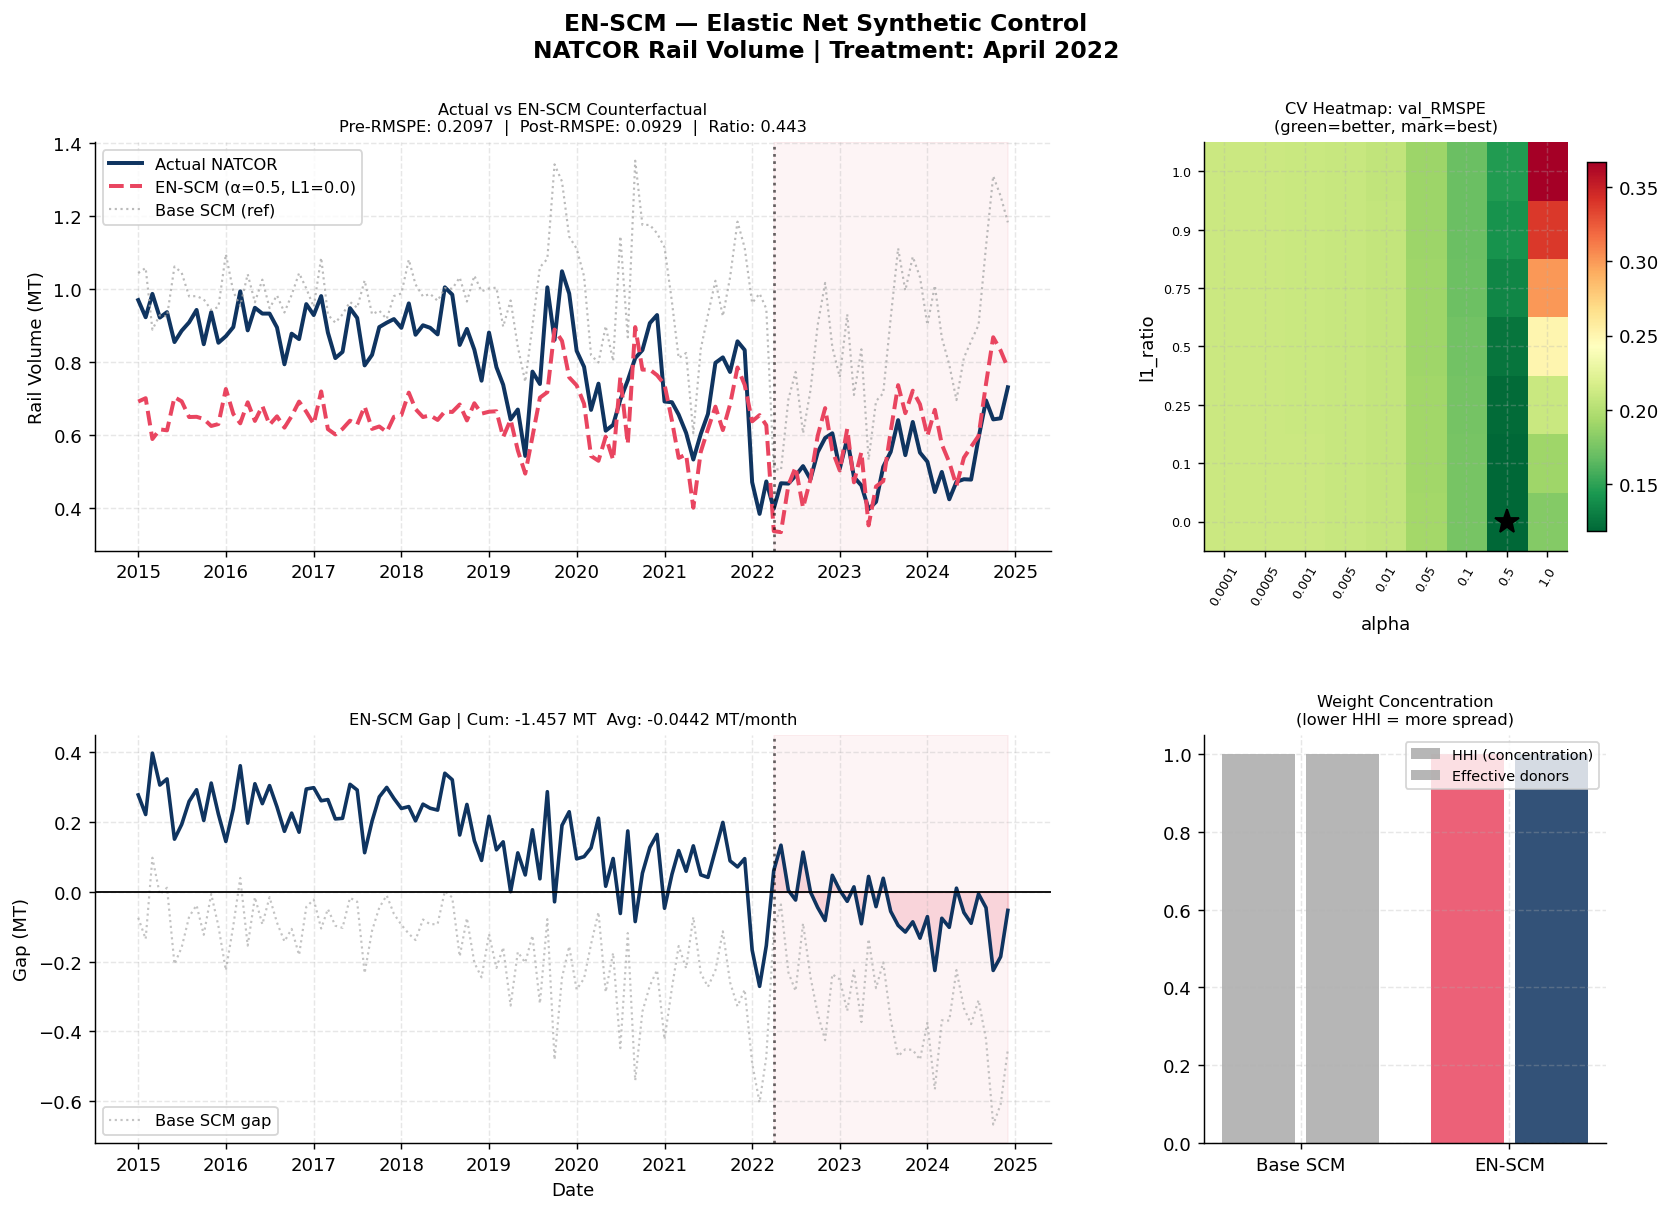

Saved → enscm_fig1_main_panel.png


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Figure 1: Main diagnostic panel
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.38)

# ── Plot 1: Actual vs counterfactuals ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(t_stamps, Y_all,  color=BLUE, lw=2.2, label='Actual NATCOR')
ax1.plot(t_stamps, cf_en,  color=RED,  lw=2.2, ls='--', label=f'EN-SCM (α={BEST_ALPHA}, L1={BEST_L1_RATIO})')
ax1.plot(t_stamps, cf_scm, color=GREY, lw=1.2, ls=':',  label='Base SCM (ref)', alpha=0.8)
ax1.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax1.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax1.set_title(f'Actual vs EN-SCM Counterfactual\nPre-RMSPE: {en_pre_r:.4f}  |  Post-RMSPE: {en_post_r:.4f}  |  Ratio: {en_ratio:.3f}', fontsize=9)
ax1.set_ylabel('Rail Volume (MT)')
ax1.legend(fontsize=9)

# ── Plot 2: CV heatmap ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
pivot_cv = cv_df.pivot_table(index='l1_ratio', columns='alpha', values='val_RMSPE')
im = ax2.imshow(pivot_cv.values, aspect='auto', cmap='RdYlGn_r', origin='lower')
ax2.set_xticks(range(len(alpha_grid)))
ax2.set_xticklabels([str(a) for a in alpha_grid], rotation=60, fontsize=7)
ax2.set_yticks(range(len(l1ratio_grid)))
ax2.set_yticklabels([str(l) for l in l1ratio_grid], fontsize=7)
ax2.set_title('CV Heatmap: val_RMSPE\n(green=better, mark=best)', fontsize=9)
ax2.set_xlabel('alpha')
ax2.set_ylabel('l1_ratio')
best_row_idx = l1ratio_grid.index(BEST_L1_RATIO)
best_col_idx = alpha_grid.index(BEST_ALPHA)
ax2.plot(best_col_idx, best_row_idx, 'k*', ms=14)
plt.colorbar(im, ax=ax2, fraction=0.046)

# ── Plot 3: Gap series ────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(t_stamps, gap_en, color=BLUE, lw=2)
ax3.plot(t_stamps, Y_all - cf_scm, color=GREY, lw=1.2, ls=':', alpha=0.7, label='Base SCM gap')
ax3.axhline(0, color='black', lw=1)
ax3.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax3.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax3.fill_between(t_stamps, gap_en, 0, where=(wide.index >= TREAT_START),
                 alpha=0.18, color=RED if en_cum < 0 else BLUE)
ax3.set_title(f'EN-SCM Gap | Cum: {en_cum:.3f} MT  Avg: {en_avg:.4f} MT/month', fontsize=9)
ax3.set_ylabel('Gap (MT)')
ax3.set_xlabel('Date')
ax3.legend(fontsize=9)

# ── Plot 4: Weight & concentration comparison ─────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
methods  = ['Base SCM', 'EN-SCM']
hhis     = [herfindahl(w_scm), en_hhi]
eff_ds   = [effective_donors(w_scm), en_eff_d]
x        = np.arange(2)
ax4.bar(x - 0.2, hhis, 0.35, color=[GREY, RED], label='HHI (concentration)', alpha=0.85)
ax4.bar(x + 0.2, eff_ds, 0.35, color=[GREY, BLUE], label='Effective donors', alpha=0.85)
ax4.set_xticks(x); ax4.set_xticklabels(methods)
ax4.set_title('Weight Concentration\n(lower HHI = more spread)', fontsize=9)
ax4.legend(fontsize=8)

fig.suptitle('EN-SCM — Elastic Net Synthetic Control\nNATCOR Rail Volume | Treatment: April 2022',
             fontsize=13, fontweight='bold')
plt.savefig('enscm_fig1_main_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → enscm_fig1_main_panel.png")


## Validation A — In-Time Placebo Tests

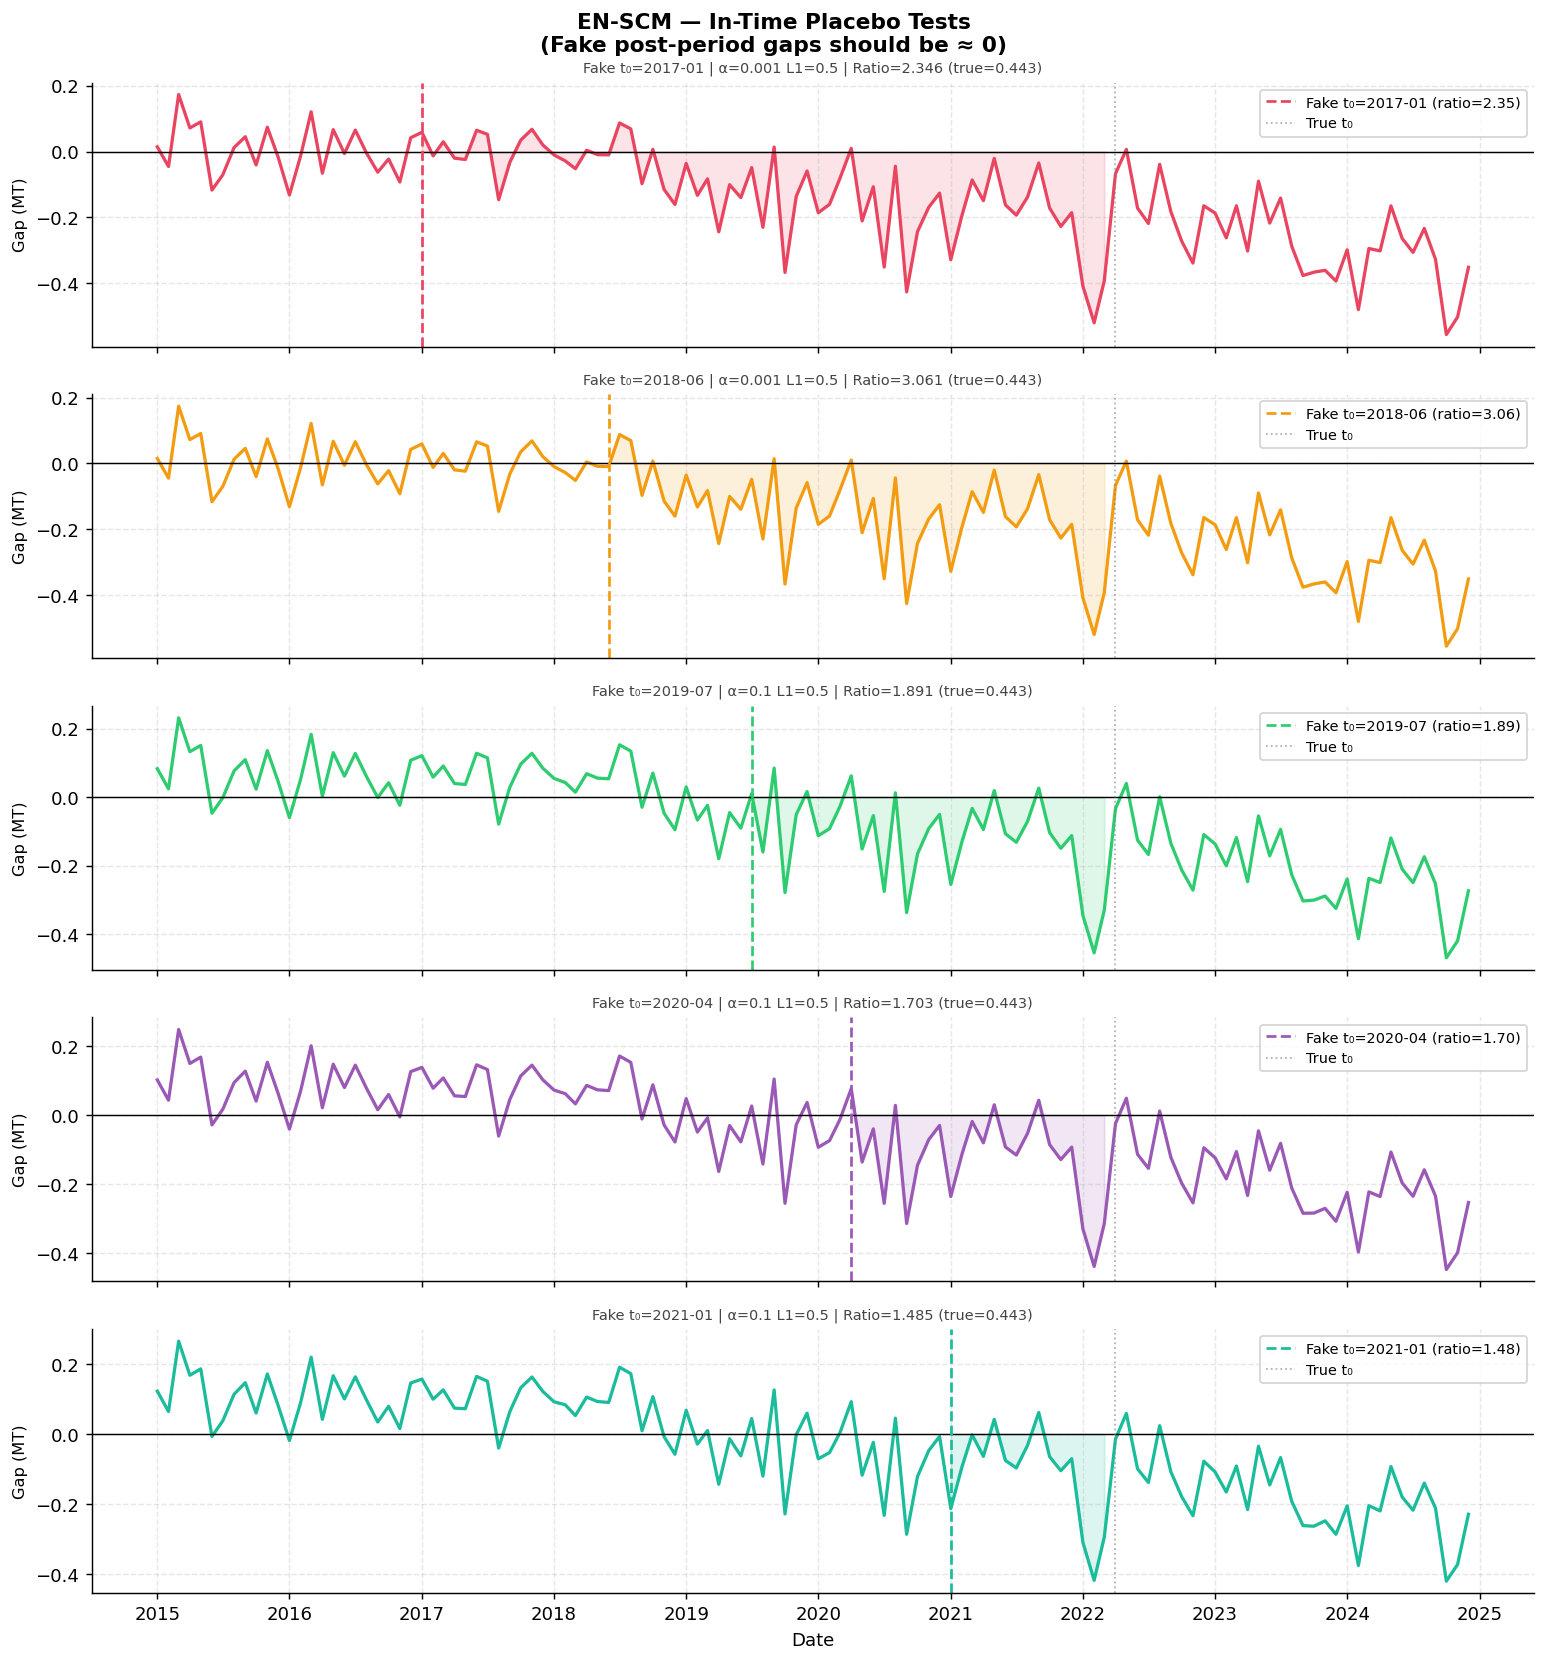

Saved → enscm_fig2_placebo.png

In-Time Placebo Summary:
Fake t₀     α  l1_ratio  Pre-RMSPE  Post-RMSPE  Ratio  > True
2017-01 0.001       0.5    0.07471     0.17526  2.346    True
2018-06 0.001       0.5    0.06603     0.20208  3.061    True
2019-07 0.100       0.5    0.09223     0.17441  1.891    True
2020-04 0.100       0.5    0.10377     0.17672  1.703    True
2021-01 0.100       0.5    0.11763     0.17466  1.485    True

True EN-SCM ratio: 0.4430
Placebo ratios > true: 5 / 5


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Validation A: In-Time Placebo Tests
# ═══════════════════════════════════════════════════════════════════════════════

placebo_dates  = [pd.Period(d, freq='M') for d in
                  ['2017-01','2018-06','2019-07','2020-04','2021-01']]
placebo_colors = [RED, AMBER, GREEN, '#9b59b6', '#1abc9c']
placebo_records = []

fig, axes = plt.subplots(len(placebo_dates), 1, figsize=(12, 13), sharex=True)
fig.suptitle('EN-SCM — In-Time Placebo Tests\n(Fake post-period gaps should be ≈ 0)', fontsize=12, fontweight='bold')

for i, fake_t in enumerate(placebo_dates):
    fake_pre  = wide.index[wide.index <= (fake_t - 1)]
    fake_post = wide.index[(wide.index >= fake_t) & (wide.index < TREAT_START)]
    if len(fake_pre) < 12 or len(fake_post) < 6: continue

    Y_fp = wide.loc[fake_pre, TREATED].values
    X_fp = wide.loc[fake_pre, donors[0]].values.reshape(-1, 1)
    sp   = int(0.6 * len(Y_fp))

    # Quick CV for this placebo period
    best_a2, best_l2, best_e2 = None, None, np.inf
    for a2, l2 in [(0.001,0.5),(0.01,0.5),(0.1,0.5),(0.01,0.25),(0.01,0.75)]:
        w2   = fit_elastic_scm(Y_fp[:sp], X_fp[:sp], alpha=a2, l1_ratio=l2)
        e2   = rmspe(Y_fp[sp:], X_fp[sp:] @ w2)
        if e2 < best_e2: best_e2, best_a2, best_l2 = e2, a2, l2

    w_fp   = fit_elastic_scm(Y_fp, X_fp, alpha=best_a2, l1_ratio=best_l2)
    cf_fp  = wide[donors[0]].values * w_fp[0]
    gap_fp = wide[TREATED].values - cf_fp

    pre_r_fp  = rmspe(Y_fp, cf_fp[:len(fake_pre)])
    post_vals = [list(wide.index).index(p) for p in fake_post]
    post_r_fp = rmspe(wide.loc[fake_post, TREATED].values, cf_fp[post_vals])
    ratio_fp  = post_r_fp / pre_r_fp if pre_r_fp > 0 else np.nan

    placebo_records.append({'Fake t₀': str(fake_t), 'α': best_a2, 'l1_ratio': best_l2,
                             'Pre-RMSPE': round(pre_r_fp, 5), 'Post-RMSPE': round(post_r_fp, 5),
                             'Ratio': round(ratio_fp, 3), '> True': ratio_fp > en_ratio})

    ax = axes[i]
    ax.plot(t_stamps, gap_fp, color=placebo_colors[i], lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(fake_t.to_timestamp(), color=placebo_colors[i], lw=1.5, ls='--',
               label=f'Fake t₀={fake_t} (ratio={ratio_fp:.2f})')
    ax.axvline(treat_t, color='grey', lw=1, ls=':', alpha=0.6, label='True t₀')
    ax.fill_between(t_stamps, gap_fp, 0,
                    where=np.array([(p >= fake_t and p < TREAT_START) for p in wide.index]),
                    alpha=0.15, color=placebo_colors[i])
    ax.set_ylabel('Gap (MT)', fontsize=9); ax.legend(fontsize=8)
    ax.set_title(f'Fake t₀={fake_t} | α={best_a2} L1={best_l2} | Ratio={ratio_fp:.3f} (true={en_ratio:.3f})',
                 fontsize=8, color='#444')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('enscm_fig2_placebo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → enscm_fig2_placebo.png")

p_df = pd.DataFrame(placebo_records)
print("\nIn-Time Placebo Summary:")
print(p_df.to_string(index=False))
print(f"\nTrue EN-SCM ratio: {en_ratio:.4f}")
print(f"Placebo ratios > true: {p_df['> True'].sum()} / {len(p_df)}")


## Validation B — Leave-One-Year-Out Stability

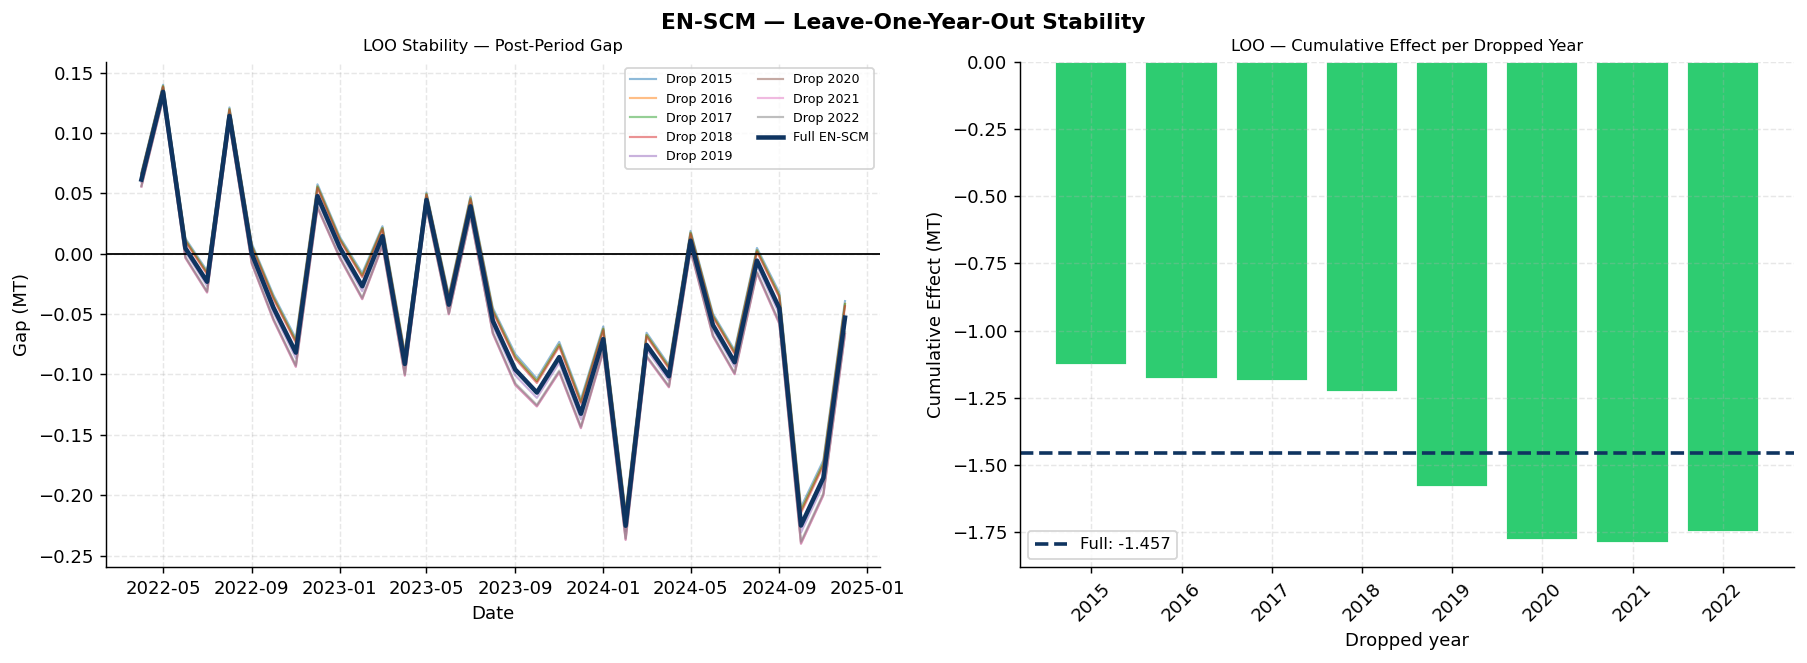

Saved → enscm_fig3_loo.png

 Drop yr  w_CAPE  HHI  Ratio  Cum effect
    2015  0.6511  1.0 0.3967     -1.1265
    2016  0.6530  1.0 0.4038     -1.1808
    2017  0.6533  1.0 0.4049     -1.1888
    2018  0.6547  1.0 0.4103     -1.2289
    2019  0.6671  1.0 0.4625     -1.5832
    2020  0.6740  1.0 0.4953     -1.7814
    2021  0.6743  1.0 0.4968     -1.7902
    2022  0.6729  1.0 0.4899     -1.7496

Full cum: -1.4575 | LOO spread: 0.6637 MT | Stable if spread < 1 MT


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Validation B: Leave-one-year-out stability
# ═══════════════════════════════════════════════════════════════════════════════

pre_years = sorted(set(pre_idx.year))
loo_records = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_g = axes[0]; ax_b = axes[1]

for yr in pre_years:
    keep = np.array([p.year != yr for p in pre_idx])
    if keep.sum() < 24: continue
    Y_loo = Y_pre_v[keep]
    X_loo = X_pre_v[keep]

    w_loo = fit_elastic_scm(Y_loo, X_loo, alpha=BEST_ALPHA, l1_ratio=BEST_L1_RATIO)
    cf_loo = X_all * w_loo[0]
    gap_loo = Y_all - cf_loo
    cum_loo = gap_loo[T_pre:].sum()
    pre_r_loo  = rmspe(Y_all[:T_pre], cf_loo[:T_pre])
    post_r_loo = rmspe(Y_all[T_pre:], cf_loo[T_pre:])
    ratio_loo  = post_r_loo / pre_r_loo

    loo_records.append({'Drop yr': yr, 'w_CAPE': round(w_loo[0], 4),
                        'HHI': round(herfindahl(w_loo), 4),
                        'Ratio': round(ratio_loo, 4), 'Cum effect': round(cum_loo, 4)})
    ax_g.plot(t_stamps[T_pre:], gap_loo[T_pre:], alpha=0.5, lw=1.2, label=f'Drop {yr}')

ax_g.plot(t_stamps[T_pre:], gap_en[T_pre:], color=BLUE, lw=2.5, label='Full EN-SCM', zorder=5)
ax_g.axhline(0, color='black', lw=1)
ax_g.set_title('LOO Stability — Post-Period Gap', fontsize=9)
ax_g.set_ylabel('Gap (MT)'); ax_g.set_xlabel('Date'); ax_g.legend(fontsize=7, ncol=2)

loo_df = pd.DataFrame(loo_records)
ax_b.bar(loo_df['Drop yr'].astype(str), loo_df['Cum effect'],
         color=[RED if abs(c - en_cum) > 0.5 else GREEN for c in loo_df['Cum effect']],
         edgecolor='white')
ax_b.axhline(en_cum, color=BLUE, lw=2, ls='--', label=f'Full: {en_cum:.3f}')
ax_b.set_title('LOO — Cumulative Effect per Dropped Year', fontsize=9)
ax_b.set_ylabel('Cumulative Effect (MT)'); ax_b.set_xlabel('Dropped year')
ax_b.legend(fontsize=9); ax_b.tick_params(axis='x', rotation=45)

plt.tight_layout()
fig.suptitle('EN-SCM — Leave-One-Year-Out Stability', fontsize=12, fontweight='bold', y=1.01)
plt.savefig('enscm_fig3_loo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → enscm_fig3_loo.png\n")
print(loo_df.to_string(index=False))
spread = loo_df['Cum effect'].max() - loo_df['Cum effect'].min()
print(f"\nFull cum: {en_cum:.4f} | LOO spread: {spread:.4f} MT | Stable if spread < 1 MT")


## Final Summary Table

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Final Summary Table
# ═══════════════════════════════════════════════════════════════════════════════

print("═" * 65)
print("EN-SCM vs BASE SCM — FINAL COMPARISON TABLE")
print("═" * 65)
rows = [
    ('Method',                  'Base SCM',            'EN-SCM'),
    ('alpha (CV-selected)',     'N/A',                 str(BEST_ALPHA)),
    ('l1_ratio (CV-selected)',  'N/A',                 str(BEST_L1_RATIO)),
    ('CAPE weight',             f'{w_scm[0]:.6f}',     f'{w_en[0]:.6f}'),
    ('Weight sum',              f'{w_scm.sum():.4f}',  f'{w_en.sum():.4f}'),
    ('HHI (concentration)',     f'{herfindahl(w_scm):.4f}', f'{en_hhi:.4f}'),
    ('Effective donors',        f'{effective_donors(w_scm):.3f}', f'{en_eff_d:.3f}'),
    ('Pre-RMSPE',               f'{base_pre_r:.4f}',   f'{en_pre_r:.4f}'),
    ('Post-RMSPE',              f'{base_post_r:.4f}',  f'{en_post_r:.4f}'),
    ('Post/Pre ratio',          f'{base_ratio:.4f}',   f'{en_ratio:.4f}'),
    ('Cumulative effect (MT)',  f'{base_cum:.4f}',     f'{en_cum:.4f}'),
    ('Avg monthly effect',      f'{(Y_all[T_pre:]-cf_scm[T_pre:]).mean():.4f}', f'{en_avg:.4f}'),
    ('Post MAPE (%)',           f'{mape(Y_all[T_pre:],cf_scm[T_pre:]):.2f}',    f'{en_mape:.2f}'),
    ('Ratio > 1',               str(base_ratio > 1),   str(en_ratio > 1)),
]
for r in rows:
    print(f"  {r[0]:<30} {r[1]:>14} {r[2]:>14}")
print("═" * 65)
print()
print("Key interpretation notes:")
print(f"  L1 ratio = {BEST_L1_RATIO} → {'pure Ridge (no sparsity)' if BEST_L1_RATIO==0 else 'pure Lasso' if BEST_L1_RATIO==1 else f'{int(BEST_L1_RATIO*100)}% Lasso / {int((1-BEST_L1_RATIO)*100)}% Ridge mix'}")
if en_hhi < herfindahl(w_scm):
    print(f"  ✓ EN-SCM reduces weight concentration (HHI {herfindahl(w_scm):.3f}→{en_hhi:.3f})")
else:
    print(f"  ~ Weight concentration unchanged (only 1 donor; L2 dominates)")
if en_pre_r < base_pre_r:
    print(f"  ✓ EN-SCM improves pre-period fit ({en_pre_r:.4f} < {base_pre_r:.4f})")
else:
    print(f"  ~ Pre-period fit similar to Base SCM (regularisation trades fit for stability)")


═════════════════════════════════════════════════════════════════
EN-SCM vs BASE SCM — FINAL COMPARISON TABLE
═════════════════════════════════════════════════════════════════
  Method                               Base SCM         EN-SCM
  alpha (CV-selected)                       N/A            0.5
  l1_ratio (CV-selected)                    N/A            0.0
  CAPE weight                          1.000000       0.662709
  Weight sum                             1.0000         0.6627
  HHI (concentration)                    1.0000         1.0000
  Effective donors                        1.000          1.000
  Pre-RMSPE                              0.2132         0.2097
  Post-RMSPE                             0.3653         0.0929
  Post/Pre ratio                         1.7140         0.4430
  Cumulative effect (MT)               -11.1040        -1.4575
  Avg monthly effect                    -0.3365        -0.0442
  Post MAPE (%)                           62.68          13.87
  Rat